In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

project_folder = Path.cwd()

if project_folder.name == "notebooks":
    project_folder = project_folder.parent

raw_folder = project_folder / "data" / "raw"
processed_folder = project_folder / "data" / "processed"

processed_folder.mkdir(
    parents=True,
    exist_ok=True
)

print("Project folder:", project_folder)


Project folder: /Users/vv/Documents/paymentguard


In [4]:
merchants = pd.read_csv(
    raw_folder / "merchants.csv",
    parse_dates=["onboarding_date"]
)

customers = pd.read_csv(
    raw_folder / "customers.csv",
    parse_dates=["account_created_at"]
)

payments = pd.read_csv(
    raw_folder / "payments.csv",
    parse_dates=["transaction_timestamp"]
)

disputes = pd.read_csv(
    raw_folder / "disputes.csv"
)

print(disputes.columns.tolist())

print("Dispute columns:")
print(disputes.columns.tolist())

possible_date_columns = [
    "dispute_created_at",
    "dispute_timestamp",
    "dispute_date"
]

date_column = next(
    (
        column
        for column in possible_date_columns
        if column in disputes.columns
    ),
    None
)

if date_column is None:
    raise ValueError(
        "No dispute date column was found."
    )

disputes[date_column] = pd.to_datetime(
    disputes[date_column]
)

if date_column != "dispute_created_at":
    disputes = disputes.rename(
        columns={
            date_column: "dispute_created_at"
        }
    )

print("Merchants:", merchants.shape)
print("Customers:", customers.shape)
print("Payments:", payments.shape)
print("Disputes:", disputes.shape)

['dispute_id', 'payment_id', 'dispute_date', 'dispute_reason', 'disputed_amount', 'dispute_fee', 'dispute_status', 'resolution_date', 'recovered_amount', 'net_dispute_loss']
Dispute columns:
['dispute_id', 'payment_id', 'dispute_date', 'dispute_reason', 'disputed_amount', 'dispute_fee', 'dispute_status', 'resolution_date', 'recovered_amount', 'net_dispute_loss']
Merchants: (100, 10)
Customers: (10000, 9)
Payments: (50000, 28)
Disputes: (834, 10)


In [7]:
merchant_columns = [
    "merchant_id",
    "merchant_name",
    "industry",
    "merchant_country",
    "merchant_size",
    "risk_category",
    "platform_type",
    "reserve_rate",
    "expected_monthly_volume"
]

customer_columns = [
    "customer_id",
    "customer_country",
    "account_created_at",
    "customer_segment",
    "historical_orders",
    "historical_chargebacks",
    "email_age_days",
    "usual_device_id",
    "lifetime_value"
]

dispute_columns = [
    "dispute_id",
    "payment_id",
    "dispute_date",
    "dispute_reason",
    "disputed_amount",
    "dispute_fee",
    "dispute_status",
    "resolution_date",
    "recovered_amount",
    "net_dispute_loss"
]

analysis = (
    payments
    .merge(
        merchants[merchant_columns],
        on="merchant_id",
        how="left",
        validate="many_to_one"
    )
    .merge(
        customers[customer_columns],
        on="customer_id",
        how="left",
        validate="many_to_one"
    )
   .merge(
    disputes,
    on="payment_id",
    how="left",
    validate="one_to_one"
)
)

print("Enriched analysis table:", analysis.shape)
print(
    "Duplicate payment IDs:",
    analysis["payment_id"].duplicated().sum()
)

Enriched analysis table: (50000, 53)
Duplicate payment IDs: 0


In [9]:
analysis["transaction_month"] = (
    analysis["transaction_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

analysis["approved_flag"] = (
    analysis["authorisation_status"]
    == "Approved"
).astype(int)

analysis["declined_flag"] = (
    analysis["authorisation_status"]
    == "Declined"
).astype(int)

analysis["has_dispute"] = (
    analysis["dispute_id"].notna()
).astype(int)

analysis["approved_amount"] = np.where(
    analysis["approved_flag"] == 1,
    analysis["amount"],
    0
)

analysis["fraud_amount"] = np.where(
    analysis["confirmed_fraud"] == 1,
    analysis["amount"],
    0
)

analysis["gross_processing_revenue"] = np.where(
    analysis["approved_flag"] == 1,
    analysis["processing_fee"],
    0
)

analysis["disputed_amount"] = (
    analysis["disputed_amount"]
    .fillna(0)
)

analysis["dispute_fee"] = (
    analysis["dispute_fee"]
    .fillna(0)
)

text_dispute_columns = [
    "dispute_reason",
    "dispute_status",
    "dispute_status"
]

for column in text_dispute_columns:
    analysis[column] = (
        analysis[column]
        .fillna("No Dispute")
    )

analysis.head()

,payment_id,transaction_timestamp,merchant_id,customer_id,amount,currency,processing_fee,payment_method,card_type,card_network,issuer_country,billing_country,ip_country,device_type,device_id,is_new_device,is_new_customer,is_cross_border,country_mismatch_flag,velocity_1h,authentication_used,authentication_result,risk_score,decision,authorisation_status,...,expected_monthly_volume,customer_country,account_created_at,customer_segment,historical_orders,historical_chargebacks,email_age_days,usual_device_id,lifetime_value,dispute_id,dispute_created_at,dispute_reason,disputed_amount,dispute_fee,dispute_status,resolution_date,recovered_amount,net_dispute_loss,transaction_month,approved_flag,declined_flag,has_dispute,approved_amount,fraud_amount,gross_processing_revenue
0,P0004693,2025-01-01 00:01:04,M00017,C002316,45.2100,AUD,0.8300,Card,Debit,Visa,GB,GB,GB,Desktop,DEV002316,0,0,1,0,1,1,Successful,32,Approve,Approved,...,"3,726,005.8500",GB,2023-02-13,Occasional,6,0,1095,DEV002316,452.6400,NaN,NaT,No Dispute,0.0000,0.0000,No Dispute,NaN,NaN,NaN,2025-01,1,0,0,45.2100,0.0000,0.8300
1,P0043213,2025-01-01 00:39:48,M00095,C004448,283.5400,GBP,4.1700,Card,Debit,Mastercard,GB,GB,GB,Mobile,DEV004448,0,0,0,0,1,1,Successful,23,Approve,Approved,...,"1,751,099.4800",GB,2021-11-11,Loyal,90,0,1771,DEV004448,"10,052.2700",NaN,NaT,No Dispute,0.0000,0.0000,No Dispute,NaN,NaN,NaN,2025-01,1,0,0,283.5400,0.0000,4.1700
2,P0047874,2025-01-01 00:41:14,M00023,C003680,"1,022.7200",GBP,14.5200,Card,Debit,Mastercard,GB,GB,GB,Mobile,DEV003680,0,0,0,0,1,0,Not Attempted,28,Approve,Declined,...,"2,708,181.4700",GB,2023-06-30,Loyal,82,0,951,DEV003680,"8,121.8100",NaN,NaT,No Dispute,0.0000,0.0000,No Dispute,NaN,NaN,NaN,2025-01,0,1,0,0.0000,0.0000,0.0000
3,P0031576,2025-01-01 00:54:17,M00034,C005766,28.5700,USD,0.6000,Card,Debit,Visa,NL,NL,NL,Mobile,NEWDEV431973,1,0,1,0,1,1,Successful,49,Approve,Approved,...,"36,241.8100",NL,2023-10-16,Occasional,6,0,1507,DEV005766,559.5400,NaN,NaT,No Dispute,0.0000,0.0000,No Dispute,NaN,NaN,NaN,2025-01,1,0,0,28.5700,0.0000,0.6000
4,P0017855,2025-01-01 01:16:45,M00069,C007132,330.4800,CAD,4.8300,Bank Transfer,Not Applicable,Not Applicable,ES,ES,ES,Mobile,DEV007132,0,0,1,0,1,0,Not Attempted,18,Approve,Approved,...,"46,750.7900",ES,2017-08-07,Loyal,82,0,3636,DEV007132,"4,433.7900",NaN,NaT,No Dispute,0.0000,0.0000,No Dispute,NaN,NaN,NaN,2025-01,1,0,0,330.4800,0.0000,4.8300


In [10]:
total_attempts = len(analysis)

approved_payments = int(
    analysis["approved_flag"].sum()
)

declined_payments = int(
    analysis["declined_flag"].sum()
)

approved_volume = analysis[
    "approved_amount"
].sum()

approval_rate = (
    approved_payments / total_attempts
)

fraud_count = int(
    analysis["confirmed_fraud"].sum()
)

fraud_rate = (
    fraud_count / approved_payments
)

dispute_count = int(
    analysis["has_dispute"].sum()
)

dispute_rate = (
    dispute_count / approved_payments
)

gross_processing_revenue = analysis[
    "gross_processing_revenue"
].sum()

headline_metrics = pd.Series(
    {
        "Payment attempts": total_attempts,
        "Approved payments": approved_payments,
        "Declined payments": declined_payments,
        "Approved volume": approved_volume,
        "Approval rate": approval_rate,
        "Confirmed fraud cases": fraud_count,
        "Fraud rate": fraud_rate,
        "Disputes": dispute_count,
        "Dispute rate": dispute_rate,
        "Gross processing revenue": (
            gross_processing_revenue
        )
    }
)

headline_metrics

Payment attempts              50,000.0000
Approved payments             44,471.0000
Declined payments              5,529.0000
Approved volume            6,154,290.9100
Approval rate                      0.8894
Confirmed fraud cases            354.0000
Fraud rate                         0.0080
Disputes                         834.0000
Dispute rate                       0.0188
Gross processing revenue      95,053.6400
dtype: float64

In [11]:
print("Total attempts:", total_attempts)

print(
    "Approved plus declined:",
    approved_payments + declined_payments
)

assert (
    total_attempts
    == approved_payments + declined_payments
)

print(
    "PASSED: attempts equal approved plus declined."
)

Total attempts: 50000
Approved plus declined: 50000
PASSED: attempts equal approved plus declined.


In [12]:
monthly_summary = (
    analysis.groupby(
        "transaction_month",
        as_index=False
    )
    .agg(
        payment_attempts=("payment_id", "count"),
        approved_payments=("approved_flag", "sum"),
        declined_payments=("declined_flag", "sum"),
        approved_volume=("approved_amount", "sum"),
        confirmed_fraud=("confirmed_fraud", "sum"),
        fraud_amount=("fraud_amount", "sum"),
        disputes=("has_dispute", "sum"),
        gross_processing_revenue=(
            "gross_processing_revenue",
            "sum"
        )
    )
)

monthly_summary["approval_rate"] = (
    monthly_summary["approved_payments"]
    / monthly_summary["payment_attempts"]
)

monthly_summary["fraud_rate"] = (
    monthly_summary["confirmed_fraud"]
    / monthly_summary["approved_payments"]
)

monthly_summary["dispute_rate"] = (
    monthly_summary["disputes"]
    / monthly_summary["approved_payments"]
)

monthly_summary.round(4)

,transaction_month,payment_attempts,approved_payments,declined_payments,approved_volume,confirmed_fraud,fraud_amount,disputes,gross_processing_revenue,approval_rate,fraud_rate,dispute_rate
0,2025-01,2167,1945,222,"268,777.0900",10,"2,246.0400",37,"4,151.8700",0.8976,0.0051,0.0190
1,2025-02,2068,1869,199,"264,193.6500",6,716.6100,24,"4,072.5400",0.9038,0.0032,0.0128
2,2025-03,2512,2239,273,"296,967.3500",19,"3,817.2000",39,"4,605.2500",0.8913,0.0085,0.0174
3,2025-04,2746,2466,280,"310,561.3600",16,"4,118.6500",35,"4,841.0400",0.8980,0.0065,0.0142
4,2025-05,3243,2891,352,"394,313.6700",20,"1,204.9500",44,"6,098.7200",0.8915,0.0069,0.0152
5,2025-06,3814,3426,388,"550,254.5400",18,"4,837.3700",73,"8,388.8400",0.8983,0.0053,0.0213
6,2025-07,4154,3733,421,"591,545.0100",30,"4,507.3800",74,"9,027.9900",0.8987,0.0080,0.0198
7,2025-08,4420,3942,478,"614,982.2200",24,"3,869.7500",84,"9,397.9000",0.8919,0.0061,0.0213
8,2025-09,3873,3429,444,"464,374.6600",23,"2,303.8300",64,"7,187.0200",0.8854,0.0067,0.0187
9,2025-10,4570,4042,528,"540,178.2000",88,"12,708.6600",90,"8,370.6300",0.8845,0.0218,0.0223


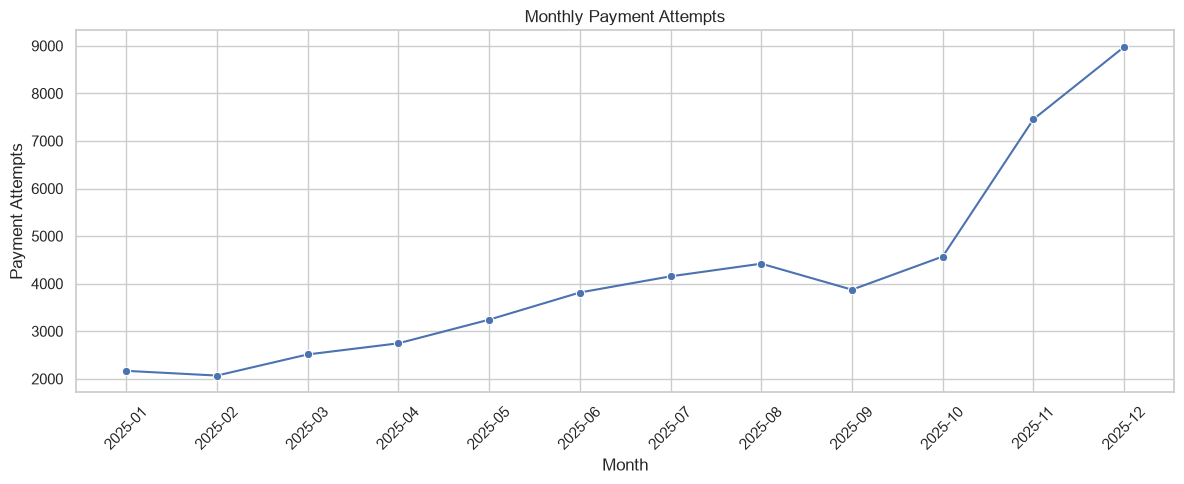

In [13]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_summary,
    x="transaction_month",
    y="payment_attempts",
    marker="o"
)

plt.title("Monthly Payment Attempts")
plt.xlabel("Month")
plt.ylabel("Payment Attempts")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

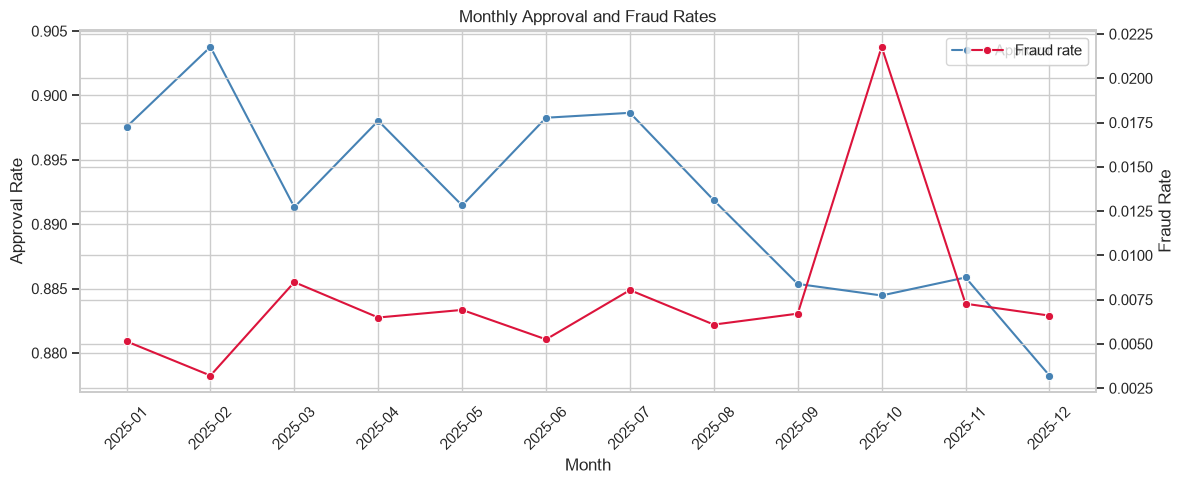

In [14]:
figure, first_axis = plt.subplots(
    figsize=(12, 5)
)

sns.lineplot(
    data=monthly_summary,
    x="transaction_month",
    y="approval_rate",
    marker="o",
    color="steelblue",
    label="Approval rate",
    ax=first_axis
)

first_axis.set_ylabel("Approval Rate")
first_axis.set_xlabel("Month")
first_axis.tick_params(
    axis="x",
    rotation=45
)

second_axis = first_axis.twinx()

sns.lineplot(
    data=monthly_summary,
    x="transaction_month",
    y="fraud_rate",
    marker="o",
    color="crimson",
    label="Fraud rate",
    ax=second_axis
)

second_axis.set_ylabel("Fraud Rate")

plt.title("Monthly Approval and Fraud Rates")
figure.tight_layout()
plt.show()

In [15]:
industry_summary = (
    analysis.groupby(
        "industry",
        as_index=False
    )
    .agg(
        payment_attempts=("payment_id", "count"),
        approved_payments=("approved_flag", "sum"),
        approved_volume=("approved_amount", "sum"),
        confirmed_fraud=("confirmed_fraud", "sum"),
        fraud_amount=("fraud_amount", "sum"),
        disputes=("has_dispute", "sum"),
        gross_processing_revenue=(
            "gross_processing_revenue",
            "sum"
        )
    )
)

industry_summary["approval_rate"] = (
    industry_summary["approved_payments"]
    / industry_summary["payment_attempts"]
)

industry_summary["fraud_rate"] = (
    industry_summary["confirmed_fraud"]
    / industry_summary["approved_payments"]
)

industry_summary["dispute_rate"] = (
    industry_summary["disputes"]
    / industry_summary["approved_payments"]
)

industry_summary.sort_values(
    "fraud_rate",
    ascending=False
).round(4)

,industry,payment_attempts,approved_payments,approved_volume,confirmed_fraud,fraud_amount,disputes,gross_processing_revenue,approval_rate,fraud_rate,dispute_rate
1,Electronics,2444,2129,"809,932.0800",25,"10,718.7600",40,"11,764.6500",0.8711,0.0117,0.0188
8,Travel,6001,5169,"2,780,540.5900",57,"28,151.7100",153,"39,961.2700",0.8614,0.0110,0.0296
0,Digital Products,9376,8203,"317,344.9200",88,"3,124.6400",132,"6,083.3300",0.8749,0.0107,0.0161
4,Gaming,7423,6559,"177,112.7900",62,"1,638.5700",129,"3,791.4100",0.8836,0.0095,0.0197
7,Ticketing,4208,3663,"482,637.7800",31,"3,493.3300",85,"7,489.5700",0.8705,0.0085,0.0232
3,Food Delivery,6680,6114,"154,532.7900",34,868.8300,94,"3,386.1100",0.9153,0.0056,0.0154
2,Fashion,6639,6024,"417,243.8500",28,"1,935.3800",105,"7,046.2500",0.9074,0.0046,0.0174
5,Marketplace,1975,1793,"432,946.0400",8,"1,994.8700",24,"6,419.7500",0.9078,0.0045,0.0134
6,Subscription Software,5254,4817,"582,000.0700",21,"3,062.6600",72,"9,111.3000",0.9168,0.0044,0.0149


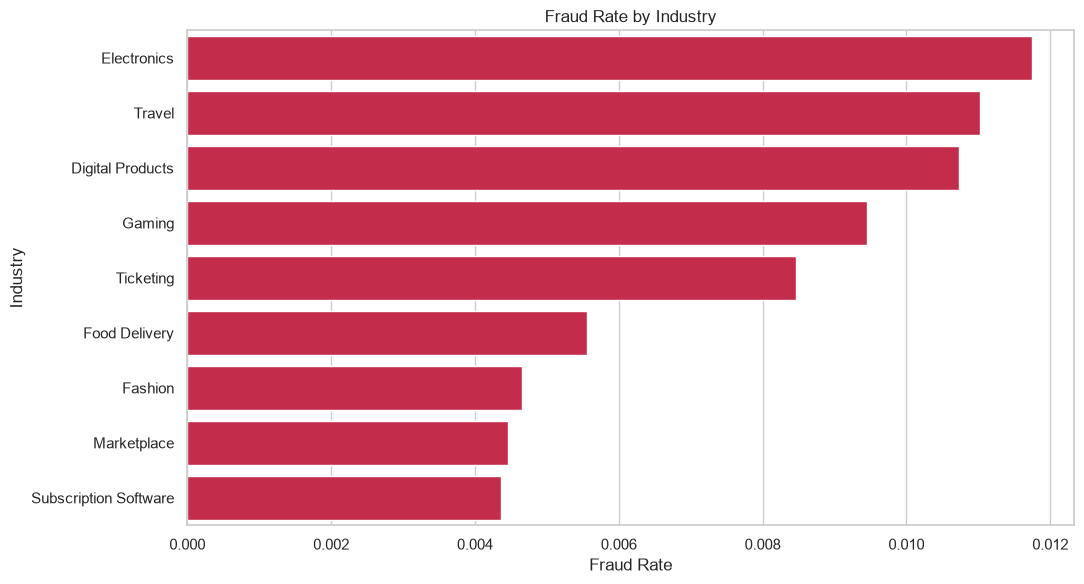

In [16]:
industry_chart_data = industry_summary.sort_values(
    "fraud_rate",
    ascending=False
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=industry_chart_data,
    x="fraud_rate",
    y="industry",
    color="crimson"
)

plt.title("Fraud Rate by Industry")
plt.xlabel("Fraud Rate")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()

In [18]:
customer_risk_summary = (
    analysis.groupby(
        "customer_segment",
        as_index=False
    )
    .agg(
        attempts=("payment_id", "count"),
        approved=("approved_flag", "sum"),
        fraud=("confirmed_fraud", "sum"),
        disputes=("has_dispute", "sum")
    )
)

customer_risk_summary["approval_rate"] = (
    customer_risk_summary["approved"]
    / customer_risk_summary["attempts"]
)

customer_risk_summary["fraud_rate"] = (
    customer_risk_summary["fraud"]
    / customer_risk_summary["approved"]
)

customer_risk_summary["dispute_rate"] = (
    customer_risk_summary["disputes"]
    / customer_risk_summary["approved"]
)

customer_risk_summary.round(4)

,customer_segment,attempts,approved,fraud,disputes,approval_rate,fraud_rate,dispute_rate
0,Loyal,4794,4279,32,97,0.8926,0.0075,0.0227
1,New,12614,10943,88,192,0.8675,0.0080,0.0175
2,Occasional,17613,15781,120,287,0.8960,0.0076,0.0182
3,Returning,14979,13468,114,258,0.8991,0.0085,0.0192


In [19]:
device_risk_summary = (
    analysis.groupby(
        "is_new_device",
        as_index=False
    )
    .agg(
        attempts=("payment_id", "count"),
        approved=("approved_flag", "sum"),
        fraud=("confirmed_fraud", "sum"),
        disputes=("has_dispute", "sum"),
        average_risk_score=("risk_score", "mean")
    )
)

device_risk_summary["approval_rate"] = (
    device_risk_summary["approved"]
    / device_risk_summary["attempts"]
)

device_risk_summary["fraud_rate"] = (
    device_risk_summary["fraud"]
    / device_risk_summary["approved"]
)

device_risk_summary["dispute_rate"] = (
    device_risk_summary["disputes"]
    / device_risk_summary["approved"]
)

device_risk_summary.round(4)

,is_new_device,attempts,approved,fraud,disputes,average_risk_score,approval_rate,fraud_rate,dispute_rate
0,0,42101,38117,273,705,29.1938,0.9054,0.0072,0.0185
1,1,7899,6354,81,129,46.1485,0.8044,0.0127,0.0203


In [20]:
authentication_summary = (
    analysis.groupby(
        "authentication_result",
        as_index=False
    )
    .agg(
        attempts=("payment_id", "count"),
        approved=("approved_flag", "sum"),
        fraud=("confirmed_fraud", "sum"),
        average_risk_score=("risk_score", "mean")
    )
)

authentication_summary["approval_rate"] = (
    authentication_summary["approved"]
    / authentication_summary["attempts"]
)

authentication_summary["fraud_rate"] = (
    authentication_summary["fraud"]
    / authentication_summary["approved"]
)

authentication_summary.round(4)

,authentication_result,attempts,approved,fraud,average_risk_score,approval_rate,fraud_rate
0,Failed,3421,1365,15,45.7951,0.3990,0.0110
1,Not Attempted,15276,14197,71,22.2097,0.9294,0.0050
2,Successful,31303,28909,268,35.0661,0.9235,0.0093


In [21]:
payment_method_summary = (
    analysis.groupby(
        "payment_method",
        as_index=False
    )
    .agg(
        attempts=("payment_id", "count"),
        approved=("approved_flag", "sum"),
        approved_volume=("approved_amount", "sum"),
        fraud=("confirmed_fraud", "sum"),
        disputes=("has_dispute", "sum")
    )
)

payment_method_summary["approval_rate"] = (
    payment_method_summary["approved"]
    / payment_method_summary["attempts"]
)

payment_method_summary["fraud_rate"] = (
    payment_method_summary["fraud"]
    / payment_method_summary["approved"]
)

payment_method_summary["dispute_rate"] = (
    payment_method_summary["disputes"]
    / payment_method_summary["approved"]
)

payment_method_summary.round(4)

,payment_method,attempts,approved,approved_volume,fraud,disputes,approval_rate,fraud_rate,dispute_rate
0,Bank Transfer,4007,3639,"520,824.8500",34,70,0.9082,0.0093,0.0192
1,Card,36020,31962,"4,431,390.6900",248,605,0.8873,0.0078,0.0189
2,Digital Wallet,9973,8870,"1,202,075.3700",72,159,0.8894,0.0081,0.0179


In [22]:
monthly_fraud_ranking = monthly_summary[
    [
        "transaction_month",
        "confirmed_fraud",
        "fraud_amount",
        "fraud_rate"
    ]
].sort_values(
    "fraud_rate",
    ascending=False
)

monthly_fraud_ranking.round(4)

,transaction_month,confirmed_fraud,fraud_amount,fraud_rate
9,2025-10,88,"12,708.6600",0.0218
2,2025-03,19,"3,817.2000",0.0085
6,2025-07,30,"4,507.3800",0.0080
10,2025-11,48,"7,260.4000",0.0073
4,2025-05,20,"1,204.9500",0.0069
8,2025-09,23,"2,303.8300",0.0067
11,2025-12,52,"7,397.9100",0.0066
3,2025-04,16,"4,118.6500",0.0065
7,2025-08,24,"3,869.7500",0.0061
5,2025-06,18,"4,837.3700",0.0053


In [23]:
merchant_24 = analysis[
    analysis["merchant_id"] == "M00024"
].copy()

merchant_24["period"] = np.where(
    merchant_24["transaction_timestamp"]
    < pd.Timestamp("2025-10-01"),
    "Jan-Sep",
    "Oct-Dec"
)

merchant_24_summary = (
    merchant_24.groupby(
        "period",
        as_index=False
    )
    .agg(
        attempts=("payment_id", "count"),
        approved=("approved_flag", "sum"),
        authentication_failures=(
            "authentication_result",
            lambda values: (
                values == "Failed"
            ).sum()
        ),
        confirmed_fraud=("confirmed_fraud", "sum")
    )
)

merchant_24_summary["approval_rate"] = (
    merchant_24_summary["approved"]
    / merchant_24_summary["attempts"]
)

merchant_24_summary[
    "authentication_failure_rate"
] = (
    merchant_24_summary[
        "authentication_failures"
    ]
    / merchant_24_summary["attempts"]
)

merchant_24_summary["fraud_rate"] = (
    merchant_24_summary["confirmed_fraud"]
    / merchant_24_summary["approved"]
)

merchant_24_summary.round(4)

,period,attempts,approved,authentication_failures,confirmed_fraud,approval_rate,authentication_failure_rate,fraud_rate
0,Jan-Sep,114,100,9,0,0.8772,0.0789,0.0000
1,Oct-Dec,93,70,17,0,0.7527,0.1828,0.0000


In [24]:
analysis.to_csv(
    processed_folder / "payment_analysis.csv",
    index=False,
    date_format="%Y-%m-%d %H:%M:%S"
)

monthly_summary.to_csv(
    processed_folder / "monthly_summary.csv",
    index=False
)

industry_summary.to_csv(
    processed_folder / "industry_summary.csv",
    index=False
)

payment_method_summary.to_csv(
    processed_folder / "payment_method_summary.csv",
    index=False
)

print("Saved:")
print(processed_folder / "payment_analysis.csv")
print(processed_folder / "monthly_summary.csv")
print(processed_folder / "industry_summary.csv")
print(processed_folder / "payment_method_summary.csv")

Saved:
/Users/vv/Documents/paymentguard/data/processed/payment_analysis.csv
/Users/vv/Documents/paymentguard/data/processed/monthly_summary.csv
/Users/vv/Documents/paymentguard/data/processed/industry_summary.csv
/Users/vv/Documents/paymentguard/data/processed/payment_method_summary.csv


In [25]:
assert len(analysis) == 50_000
assert analysis["payment_id"].is_unique
assert analysis["merchant_name"].notna().all()
assert analysis["customer_segment"].notna().all()

assert analysis["has_dispute"].sum() == len(
    disputes
)

assert (
    total_attempts
    == approved_payments + declined_payments
)

assert len(monthly_summary) == 12

assert monthly_summary[
    "approval_rate"
].between(0, 1).all()

assert monthly_summary[
    "fraud_rate"
].between(0, 1).all()

assert monthly_summary[
    "dispute_rate"
].between(0, 1).all()

print(
    "PART 6 PASSED: exploratory analysis is complete."
)

PART 6 PASSED: exploratory analysis is complete.
